# Airline Reviews NLP Pipeline

Union two review datasets, clean and transform text, and run NLP analysis for later modeling.

Phases:
- Phase 1: data collection (raw + scraped + web-scraped)
- Phase 2: cleaning, lemmatization (spaCy), URL / proper-name / stopword filtering
- Phase 3: exploratory data analysis (class balance, length, word frequency, word cloud)
- Phase 4: **baseline ML benchmark** — Logistic Regression + Multinomial NB on TF-IDF features, with **SMOTE** class balancing
- Phase 5: vectorization (TF-IDF + DistilBERT embeddings) and sentiment models (VADER + DistilBERT)
- Phase 6: topic modeling (LDA, k=5, with **human-readable topic labels**) + NER (spaCy)
- Phase 7: visualization, validation, and export


In [ ]:
# 0) Install Required Libraries (and spaCy English model)
import subprocess, sys

packages = [
    "numpy",
    "pandas",
    "scikit-learn",
    "scipy",
    "matplotlib",
    "seaborn",
    "wordcloud",
    "nltk",
    "spacy",
    "transformers",
    "torch",
    "requests",
    "beautifulsoup4",
    "imbalanced-learn",   # SMOTE for class balancing
    "joblib",             # persist baseline models for the web API
]

def pip_install(*args):
    """Install with --user to avoid system-Python permission errors on Windows."""
    return subprocess.run(
        [sys.executable, "-m", "pip", "install", *args, "--user", "--quiet"],
        capture_output=True, text=True,
    )

for pkg in packages:
    result = pip_install(pkg)
    status = "OK" if result.returncode == 0 else f"FAILED: {result.stderr.strip()[:120]}"
    print(f"  {pkg:25s} {status}")

# spaCy English model (required for NER + lemmatization + proper-noun filtering)
spacy_model_check = subprocess.run(
    [sys.executable, "-c", "import spacy; spacy.load('en_core_web_sm')"],
    capture_output=True, text=True,
)
if spacy_model_check.returncode != 0:
    print("  Installing spaCy model en_core_web_sm ...")
    r = subprocess.run(
        [sys.executable, "-m", "spacy", "download", "en_core_web_sm", "--user"],
        capture_output=True, text=True,
    )
    msg = "OK" if r.returncode == 0 else f"FAILED: {r.stderr.strip()[:120]}"
    print(f"  {'en_core_web_sm':25s} {msg}")
else:
    print(f"  {'en_core_web_sm':25s} OK (already installed)")

print("\nAll packages processed.")


  numpy                     OK
  pandas                    OK
  scikit-learn              OK
  scipy                     OK
  matplotlib                OK
  seaborn                   OK
  wordcloud                 OK
  nltk                      OK
  spacy                     OK
  transformers              OK
  torch                     OK
  requests                  OK
  beautifulsoup4            OK
  en_core_web_sm            OK (already installed)

All packages processed.


In [1]:
# 1) Import Libraries and Set Paths
from pathlib import Path
import re
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# ----- NLP libs (must succeed; cell 0 installs them) -----
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)
nltk.download("punkt", quiet=True)

import spacy
from transformers import pipeline, AutoTokenizer, AutoModel
import torch

print("Torch CUDA available:", torch.cuda.is_available())
DEVICE = 0 if torch.cuda.is_available() else -1

# ── Resolve project root portably ─────────────────────────────────────────────
# Notebook location is "<project>/10_NLP/airline_reviews_nlp_pipeline.ipynb".
# Walk up from cwd until we find the "10_NLP" folder so paths work on any machine.
def _find_nlp_dir() -> Path:
    here = Path.cwd().resolve()
    # 1) cwd already IS 10_NLP
    if here.name == "10_NLP" and (here / "airline_reviews_raw_data.csv").exists():
        return here
    # 2) cwd CONTAINS 10_NLP (running from project root)
    candidate = here / "10_NLP"
    if candidate.exists() and (candidate / "airline_reviews_raw_data.csv").exists():
        return candidate
    # 3) walk up
    for parent in here.parents:
        candidate = parent / "10_NLP"
        if candidate.exists() and (candidate / "airline_reviews_raw_data.csv").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate '10_NLP' folder starting from {here}. "
        "Run the notebook from inside the SkyInsight project."
    )

NLP_DIR          = _find_nlp_dir()
RAW_PATH         = NLP_DIR / "airline_reviews_raw_data.csv"
SCRAPED_PATH     = NLP_DIR / "airline_reviews_scraped.csv"
WEB_SCRAPED_PATH = NLP_DIR / "airline_reviews_web_scraped.csv"
OUTPUT_DIR       = NLP_DIR / "outputs_nlp"
MODELS_DIR       = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("NLP dir :", NLP_DIR)
print("Output  :", OUTPUT_DIR)
print("Models  :", MODELS_DIR)


Torch CUDA available: False
NLP dir : C:\Users\moham\SkyInsight\10_NLP
Output  : C:\Users\moham\SkyInsight\10_NLP\outputs_nlp
Models  : C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\models


In [2]:
# 2) Load Raw, Scraped, and Web-Scraped CSV Files
def safe_read_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, encoding="utf-8", encoding_errors="ignore")

def normalize_rating(df: pd.DataFrame, scale_max: int, data_source: str) -> pd.DataFrame:
    """Add `rating_norm` (1-5 scale) and `true_label` (positive/neutral/negative)."""
    df = df.copy()
    df["data_source"] = data_source
    if "rating" in df.columns:
        r = pd.to_numeric(df["rating"], errors="coerce")
        # Map ratings to a common 1-5 scale.
        if scale_max == 10:
            df["rating_norm"] = (r / 2.0).round(2)
        else:
            df["rating_norm"] = r.astype(float)
    else:
        df["rating_norm"] = np.nan
    # Star → polarity
    def _to_label(x):
        if pd.isna(x):
            return None
        if x >= 4:
            return "positive"
        if x <= 2:
            return "negative"
        return "neutral"
    df["true_label"] = df["rating_norm"].apply(_to_label)
    # Standardise the date column (string) so downstream code can parse safely.
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date.astype(str)
    return df

df_raw         = normalize_rating(safe_read_csv(RAW_PATH),         scale_max=5,  data_source="raw")
df_scraped     = normalize_rating(safe_read_csv(SCRAPED_PATH),     scale_max=5,  data_source="scraped")
df_web_scraped = normalize_rating(safe_read_csv(WEB_SCRAPED_PATH), scale_max=10, data_source="web")

# Limit raw data before union (was 2000)
df_raw = df_raw.head(2000)

print("Raw shape:",         df_raw.shape)
print("Scraped shape:",     df_scraped.shape)
print("Web-scraped shape:", df_web_scraped.shape)
print("\nTrue-label distribution per source:")
for name, df in [("raw", df_raw), ("scraped", df_scraped), ("web", df_web_scraped)]:
    print(f"  {name:8s}", df["true_label"].value_counts(dropna=False).to_dict())

display(df_raw.head(3))
display(df_scraped.head(3))
display(df_web_scraped.head(3))
print("Raw columns:",         df_raw.columns.tolist())
print("Scraped columns:",     df_scraped.columns.tolist())
print("Web-scraped columns:", df_web_scraped.columns.tolist())


Raw shape: (2000, 9)
Scraped shape: (897, 9)
Web-scraped shape: (750, 9)

True-label distribution per source:
  raw      {'negative': 1101, 'positive': 899}
  scraped  {'positive': 652, 'neutral': 124, 'negative': 121}
  web      {'negative': 502, 'positive': 172, 'neutral': 76}


,airline,source,review_text,rating,date,verified_purchase,data_source,rating_norm,true_label
0,Talyena Airlines,repo_satisfaction_ratings,Seat Comfort was excellent. Food and Drink was...,2,2026-05-02,yes,raw,2.0,negative
1,Talyena Airlines,repo_satisfaction_ratings,Seat Comfort was good. Food and Drink was aver...,4,2026-05-02,yes,raw,4.0,positive
2,Talyena Airlines,repo_satisfaction_ratings,Seat Comfort was excellent. Food and Drink was...,4,2026-05-02,yes,raw,4.0,positive


,airline,source,review_text,rating,date,verified_purchase,data_source,rating_norm,true_label
0,Lufthansa,pullpush_reddit,Airlines Are Collecting Your Data And Selling ...,4,2026-05-02,unknown,scraped,4.0,positive
1,Southwest Airlines,pullpush_reddit,Explore Multi-City Flight Packages with Car an...,5,2026-05-02,unknown,scraped,5.0,positive
2,Qatar Airways,pullpush_reddit,"Critical News Committee - May 7th, 2025. https...",5,2026-05-02,unknown,scraped,5.0,positive


,airline,source,review_text,rating,date,verified_purchase,data_source,rating_norm,true_label
0,Emirates,skytrax,"Like others, having a complete headache gettin...",1,2026-05-01,unknown,web,0.5,negative
1,Emirates,skytrax,"Due to the war situation in the Middle East, I...",1,2026-04-30,unknown,web,0.5,negative
2,Emirates,skytrax,I recently booked a flight with Emirates from ...,1,2026-04-08,unknown,web,0.5,negative


Raw columns: ['airline', 'source', 'review_text', 'rating', 'date', 'verified_purchase', 'data_source', 'rating_norm', 'true_label']
Scraped columns: ['airline', 'source', 'review_text', 'rating', 'date', 'verified_purchase', 'data_source', 'rating_norm', 'true_label']
Web-scraped columns: ['airline', 'source', 'review_text', 'rating', 'date', 'verified_purchase', 'data_source', 'rating_norm', 'true_label']


In [3]:
# 3) Union the Datasets (raw + reddit-scraped + web-scraped) and Save Combined CSV
all_cols = sorted(
    set(df_raw.columns)
    .union(set(df_scraped.columns))
    .union(set(df_web_scraped.columns))
)
df_raw_aligned         = df_raw.reindex(columns=all_cols)
df_scraped_aligned     = df_scraped.reindex(columns=all_cols)
df_web_scraped_aligned = df_web_scraped.reindex(columns=all_cols)

df_all = pd.concat(
    [df_raw_aligned, df_scraped_aligned, df_web_scraped_aligned],
    ignore_index=True
)
before_dupes = len(df_all)
df_all = df_all.drop_duplicates()
after_dupes = len(df_all)

combined_path = OUTPUT_DIR / "airline_reviews_combined.csv"
df_all.to_csv(combined_path, index=False)

print(f"Sources: raw={len(df_raw)}, reddit={len(df_scraped)}, web={len(df_web_scraped)}")
print(f"Combined rows: {before_dupes} -> {after_dupes} (after dedup)")
print(f"Saved: {combined_path}")


Sources: raw=2000, reddit=897, web=750
Combined rows: 3647 -> 3346 (after dedup)
Saved: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\airline_reviews_combined.csv


In [4]:
# 4) Text Cleaning: contractions, URLs, normalization, stopwords, lemmatization, proper-name filtering
import re
import pandas as pd
import nltk
import spacy

nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

def detect_text_column(columns):
    candidates = ["review", "review_text", "text", "content", "comment", "comments", "feedback", "body", "title"]
    cols_lower = {c.lower(): c for c in columns}
    for c in candidates:
        if c in cols_lower:
            return cols_lower[c]
    for c in columns:
        if any(k in c.lower() for k in candidates):
            return c
    return None

text_col = detect_text_column(df_all.columns)
if text_col is None:
    raise ValueError("Could not detect a review text column.")
print("Text column:", text_col)

# ---- Stopword set: NLTK + airline-specific noise + custom ----
stop_words = set(stopwords.words("english"))
AIRLINE_NOISE = {
    "flight", "flights", "plane", "airline", "airlines", "airport", "airports",
    "fly", "flying", "flew", "trip", "travel", "traveled", "travelled",
    "would", "could", "got", "get", "go", "going", "went", "really", "even",
    "us", "im", "ive", "id", "dont", "didnt", "doesnt", "wasnt", "isnt",
    "one", "two", "also", "back", "much", "many", "way", "still", "ever",
    "told", "said", "say", "saying",
}
stop_words.update(AIRLINE_NOISE)

# ---- Contraction map (most common English contractions; no extra dependency) ----
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not", "'re": " are",
    "'s": " is", "'d": " would", "'ll": " will", "'t": " not",
    "'ve": " have", "'m": " am", "let's": "let us", "y'all": "you all",
    "ain't": "is not", "shouldn't": "should not", "couldn't": "could not",
    "wouldn't": "would not", "doesn't": "does not", "didn't": "did not",
    "wasn't": "was not", "weren't": "were not", "isn't": "is not",
    "aren't": "are not", "hasn't": "has not", "haven't": "have not",
    "hadn't": "had not", "don't": "do not", "i'm": "i am", "you're": "you are",
    "they're": "they are", "we're": "we are", "it's": "it is", "that's": "that is",
    "there's": "there is", "what's": "what is", "where's": "where is",
}
_CONTRACTIONS_RE = re.compile(
    "|".join(re.escape(k) for k in sorted(CONTRACTIONS, key=len, reverse=True)),
    flags=re.IGNORECASE,
)

def expand_contractions(s: str) -> str:
    def _sub(m):
        match = m.group(0)
        return CONTRACTIONS.get(match.lower(), match)
    return _CONTRACTIONS_RE.sub(_sub, s)

# ---- Regex patterns ----
URL_RE      = re.compile(r"https?://\S+|www\.\S+")
HTML_RE     = re.compile(r"<[^>]+>")
EMAIL_RE    = re.compile(r"\S+@\S+\.\S+")
NONALPHA_RE = re.compile(r"[^a-z\s]")
MULTISPACE  = re.compile(r"\s+")

def clean_text(s):
    """Light cleaning: lowercase, expand contractions, strip URLs/HTML/emails/non-alpha."""
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = expand_contractions(s)
    s = URL_RE.sub(" ", s)
    s = HTML_RE.sub(" ", s)
    s = EMAIL_RE.sub(" ", s)
    s = NONALPHA_RE.sub(" ", s)
    s = MULTISPACE.sub(" ", s).strip()
    return s

df_all["text_clean"] = df_all[text_col].apply(clean_text)
df_all = df_all.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
df_all = df_all[df_all["text_clean"].str.len() > 0].reset_index(drop=True)

# ---- spaCy: lemmatize + drop proper nouns (PROPN) and entity tokens ----
nlp_lemma = spacy.load("en_core_web_sm", disable=["parser"])

def lemmatize_and_filter(doc):
    """
    Keep only meaningful lemmas:
      - drop PROPN (proper names: airline/airport/people names)
      - drop named-entity tokens (ent_type_ != "")
      - drop stopwords, short tokens, non-alpha
      - return space-joined lemmas (singular form)
    """
    tokens = []
    for tok in doc:
        if tok.is_stop or tok.is_punct or tok.is_space:
            continue
        if not tok.is_alpha:
            continue
        if tok.pos_ == "PROPN":          # proper names removed
            continue
        if tok.ent_type_:                # tokens inside any named entity removed
            continue
        lemma = tok.lemma_.lower().strip()
        if len(lemma) < 3:
            continue
        if lemma in stop_words:
            continue
        tokens.append(lemma)
    return " ".join(tokens)

print("Lemmatizing with spaCy (this may take a minute)...")
lemmatized = []
texts_clean_list = df_all["text_clean"].tolist()
for doc in nlp_lemma.pipe(texts_clean_list, batch_size=64):
    lemmatized.append(lemmatize_and_filter(doc))

df_all["text_nostop"] = lemmatized
df_all = df_all[df_all["text_nostop"].str.split().str.len() >= 3].reset_index(drop=True)

print(f"Rows after cleaning + lemmatization: {len(df_all)}")
print("Sample cleaned/lemmatized:")
for original, lemma in list(zip(df_all["text_clean"].head(3), df_all["text_nostop"].head(3))):
    print(f"  RAW : {original[:120]}")
    print(f"  LEMMA: {lemma[:120]}\n")


Text column: review_text
Lemmatizing with spaCy (this may take a minute)...
Rows after cleaning + lemmatization: 3327
Sample cleaned/lemmatized:
  RAW : seat comfort was excellent food and drink was excellent in flight service was excellent in flight entertainment was exce
  LEMMA: excellent food drink excellent service excellent entertainment excellent baggage handling excellent cleanliness excellen

  RAW : seat comfort was good food and drink was average in flight service was excellent in flight entertainment was excellent b
  LEMMA: good food drink average service excellent entertainment excellent baggage handling excellent cleanliness excellent check

  RAW : seat comfort was excellent food and drink was excellent in flight service was average in flight entertainment was averag
  LEMMA: excellent food drink excellent service average entertainment average baggage handling average cleanliness excellent chec



Class distribution (TRUE labels from star rating):
true_label
negative    1638
positive    1489
neutral      200
Name: count, dtype: int64 

Class distribution (VADER weak label — comparison only):
eda_label
positive    2390
negative     883
neutral       54
Name: count, dtype: int64 

Text length stats (words):
count    3327.0
mean       73.8
std        43.7
min        18.0
25%        40.0
50%        45.0
75%        91.0
max       209.0
Name: word_len, dtype: float64


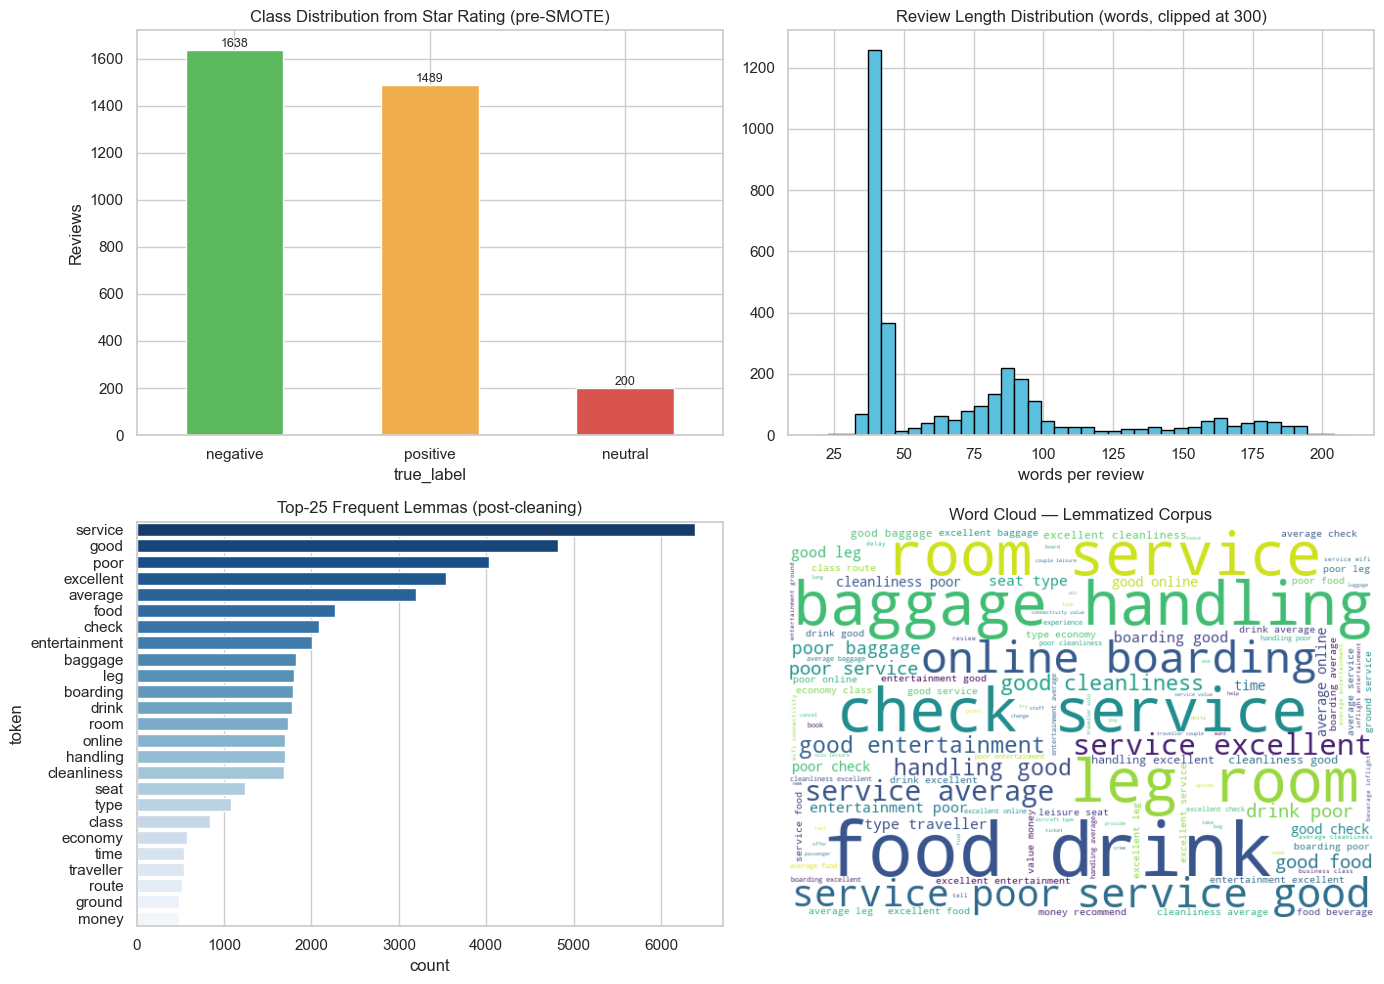


Saved EDA figure: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\nlp_eda.png


In [5]:
# 4b) Exploratory Data Analysis (EDA) — pre-modeling diagnostics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

sns.set_theme(style="whitegrid")

# ---- VADER weak-label kept as a comparison signal (NOT the supervised target) ----
import nltk
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
_sia_eda = SentimentIntensityAnalyzer()

def _quick_label(t):
    c = _sia_eda.polarity_scores(t if isinstance(t, str) else "")["compound"]
    if c >  0.05: return "positive"
    if c < -0.05: return "negative"
    return "neutral"

df_all["eda_label"] = df_all["text_clean"].apply(_quick_label)

# ---- TRUE labels (from star rating; the supervised target). Fallback to VADER where rating missing. ----
if "true_label" not in df_all.columns:
    df_all["true_label"] = None
df_all["true_label"] = df_all["true_label"].where(df_all["true_label"].notna(), df_all["eda_label"])

# ---- Length features ----
df_all["char_len"]  = df_all["text_clean"].str.len()
df_all["word_len"]  = df_all["text_clean"].str.split().str.len()

print("Class distribution (TRUE labels from star rating):")
print(df_all["true_label"].value_counts(), "\n")
print("Class distribution (VADER weak label — comparison only):")
print(df_all["eda_label"].value_counts(), "\n")
print("Text length stats (words):")
print(df_all["word_len"].describe().round(1))

# ---- Visual EDA ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) TRUE class distribution
class_counts = df_all["true_label"].value_counts()
class_counts.plot(kind="bar",
                  ax=axes[0, 0],
                  color=["#5cb85c", "#f0ad4e", "#d9534f"][:len(class_counts)])
axes[0, 0].set_title("Class Distribution from Star Rating (pre-SMOTE)")
axes[0, 0].set_ylabel("Reviews")
axes[0, 0].tick_params(axis="x", rotation=0)
for i, v in enumerate(class_counts.values):
    axes[0, 0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)

# (2) Word-count histogram
axes[0, 1].hist(df_all["word_len"].clip(upper=300), bins=40,
                color="#5bc0de", edgecolor="black")
axes[0, 1].set_title("Review Length Distribution (words, clipped at 300)")
axes[0, 1].set_xlabel("words per review")

# (3) Top-25 most frequent lemmas
all_tokens = " ".join(df_all["text_nostop"].astype(str)).split()
tok_counts = Counter(all_tokens).most_common(25)
top_df = pd.DataFrame(tok_counts, columns=["token", "count"])
sns.barplot(data=top_df, y="token", x="count", ax=axes[1, 0],
            palette="Blues_r", hue="token", legend=False)
axes[1, 0].set_title("Top-25 Frequent Lemmas (post-cleaning)")

# (4) Word cloud (all reviews)
wc = WordCloud(width=600, height=400, background_color="white",
               colormap="viridis", max_words=120).generate(" ".join(all_tokens))
axes[1, 1].imshow(wc, interpolation="bilinear")
axes[1, 1].set_title("Word Cloud — Lemmatized Corpus")
axes[1, 1].axis("off")

plt.tight_layout()
eda_path = OUTPUT_DIR / "nlp_eda.png"
plt.savefig(eda_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"\nSaved EDA figure: {eda_path}")


Baseline class distribution BEFORE SMOTE (from star rating):
negative    1638
positive    1489
neutral      200
Name: count, dtype: int64 

Usable classes: ['negative', 'positive', 'neutral']
Class distribution AFTER SMOTE (train):
negative    1310
positive    1310
neutral     1310
Name: count, dtype: int64 


=== LogisticRegression ===
  accuracy : 0.7553
  macro-F1 : 0.6418
  CV f1    : 0.6371 ± 0.0059
              precision    recall  f1-score   support

    negative       0.86      0.79      0.82       328
     neutral       0.25      0.50      0.33        40
    positive       0.79      0.75      0.77       298

    accuracy                           0.76       666
   macro avg       0.63      0.68      0.64       666
weighted avg       0.79      0.76      0.77       666


=== MultinomialNB ===
  accuracy : 0.5075
  macro-F1 : 0.4725
  CV f1    : 0.5394 ± 0.0079
              precision    recall  f1-score   support

    negative       0.75      0.57      0.64       328
     neutr

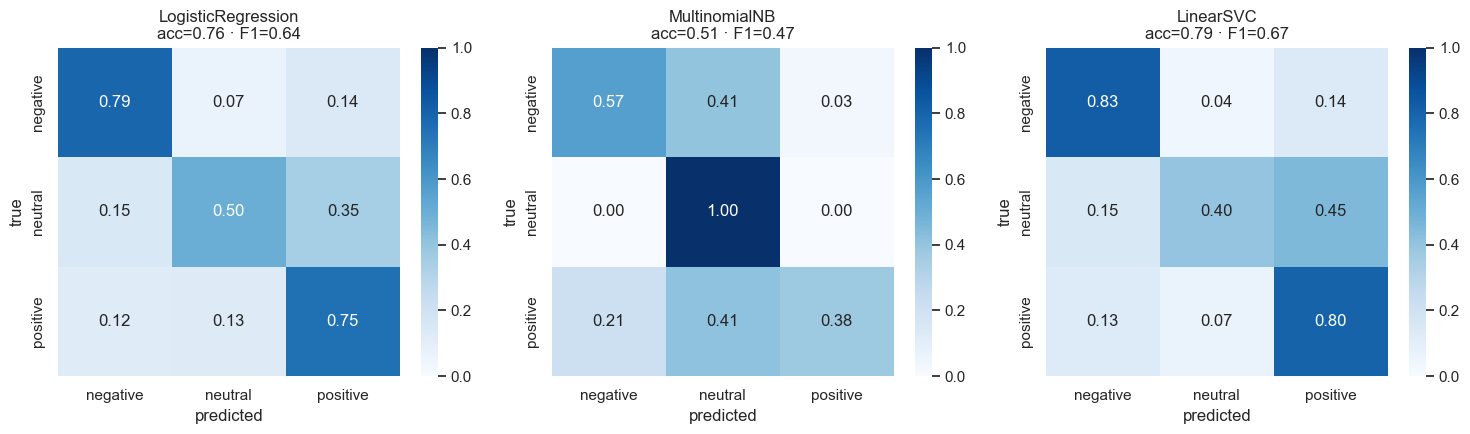


Best model: LinearSVC → persisted to C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\models
Saved baseline metrics: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\baseline_metrics.json
Saved confusion matrices: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\baseline_confusion.png


In [6]:
# 4c) Baseline ML Models (LogReg + MultinomialNB + LinearSVC) with SMOTE class balancing
# Goal: transparent benchmark using REAL star-rating labels (not VADER weak labels).
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
)
from imblearn.over_sampling import SMOTE

# ---- TRUE labels from star rating (no VADER leakage) ----
mask = df_all["true_label"].isin(["positive", "negative", "neutral"])
X_text = df_all.loc[mask, "text_nostop"].astype(str)
y      = df_all.loc[mask, "true_label"].values
print("Baseline class distribution BEFORE SMOTE (from star rating):")
print(pd.Series(y).value_counts(), "\n")

# Need ≥2 classes and ≥10 samples per class for SMOTE+CV to be meaningful
class_sizes = pd.Series(y).value_counts()
usable_classes = class_sizes[class_sizes >= 10].index.tolist()
if len(usable_classes) < 2:
    raise RuntimeError(
        f"Not enough labelled data for baseline: {class_sizes.to_dict()}. "
        "Need at least two classes with ≥10 samples."
    )
mask2 = pd.Series(y).isin(usable_classes).values
X_text = X_text[mask2]
y      = y[mask2]
print(f"Usable classes: {usable_classes}")

# ---- Train / test split (stratified) ----
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y,
)

# ---- TF-IDF features (single shared vectorizer, fit on TRAIN only) ----
baseline_vec = TfidfVectorizer(max_features=4000, ngram_range=(1, 2), min_df=2)
X_train = baseline_vec.fit_transform(X_train_text)
X_test  = baseline_vec.transform(X_test_text)

# ---- SMOTE: balance minority classes in TRAIN ONLY ----
min_count = pd.Series(y_train).value_counts().min()
k_neigh   = max(1, min(5, min_count - 1))
smote = SMOTE(random_state=42, k_neighbors=k_neigh)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("Class distribution AFTER SMOTE (train):")
print(pd.Series(y_train_bal).value_counts(), "\n")

# ---- Fit & evaluate three baselines ----
baselines = {
    "LogisticRegression": LogisticRegression(max_iter=1000, n_jobs=-1, C=1.0,
                                             class_weight="balanced"),
    "MultinomialNB":      MultinomialNB(),
    "LinearSVC":          LinearSVC(C=1.0, class_weight="balanced"),
}

labels_sorted = sorted(np.unique(y))
baseline_results = {}
fig, axes = plt.subplots(1, len(baselines), figsize=(5 * len(baselines), 4.5))
if len(baselines) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, baselines.items()):
    model.fit(X_train_bal, y_train_bal)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    # 3-fold CV (cheap, gives a stability signal)
    try:
        cv_scores = cross_val_score(
            model, X_train, y_train, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            scoring="f1_macro", n_jobs=-1,
        )
        cv_mean, cv_std = float(cv_scores.mean()), float(cv_scores.std())
    except Exception:
        cv_mean, cv_std = float("nan"), float("nan")
    baseline_results[name] = {
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(f1m), 4),
        "cv_f1_macro_mean": round(cv_mean, 4),
        "cv_f1_macro_std":  round(cv_std, 4),
        "report":   classification_report(y_test, y_pred, output_dict=True, zero_division=0),
    }
    print(f"\n=== {name} ===")
    print(f"  accuracy : {acc:.4f}")
    print(f"  macro-F1 : {f1m:.4f}")
    print(f"  CV f1    : {cv_mean:.4f} ± {cv_std:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Normalized confusion matrix (row-wise = recall)
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=labels_sorted, yticklabels=labels_sorted, vmin=0, vmax=1)
    ax.set_title(f"{name}\nacc={acc:.2f} · F1={f1m:.2f}")
    ax.set_xlabel("predicted"); ax.set_ylabel("true")

plt.tight_layout()
baseline_path = OUTPUT_DIR / "baseline_confusion.png"
plt.savefig(baseline_path, dpi=120, bbox_inches="tight")
plt.show()

# ---- Pick best model on macro-F1 and persist artifacts for the web API ----
best_name = max(baseline_results.keys(), key=lambda k: baseline_results[k]["macro_f1"])
best_model = baselines[best_name]
joblib.dump(baseline_vec, MODELS_DIR / "baseline_vectorizer.joblib")
joblib.dump(best_model,   MODELS_DIR / "baseline_best_model.joblib")
# Persist classes_ explicitly (LinearSVC doesn't expose predict_proba but does expose classes_)
joblib.dump(list(getattr(best_model, "classes_", labels_sorted)),
            MODELS_DIR / "baseline_classes.joblib")
print(f"\nBest model: {best_name} → persisted to {MODELS_DIR}")

# ---- Persist baseline metrics to JSON for the web app ----
baseline_metrics_path = OUTPUT_DIR / "baseline_metrics.json"
with open(baseline_metrics_path, "w", encoding="utf-8") as f:
    json.dump({
        "models":      list(baseline_results.keys()),
        "best_model":  best_name,
        "label_source": "star_rating",
        "results":     {k: {
                            "accuracy": v["accuracy"],
                            "macro_f1": v["macro_f1"],
                            "cv_f1_macro_mean": v["cv_f1_macro_mean"],
                            "cv_f1_macro_std":  v["cv_f1_macro_std"],
                        } for k, v in baseline_results.items()},
        "smote": {
            "k_neighbors":     int(k_neigh),
            "train_before":    {str(k): int(v) for k, v in pd.Series(y_train).value_counts().items()},
            "train_after":     {str(k): int(v) for k, v in pd.Series(y_train_bal).value_counts().items()},
        },
        "n_features": int(X_train.shape[1]),
        "n_train":    int(X_train.shape[0]),
        "n_test":     int(X_test.shape[0]),
        "artifacts":  {
            "vectorizer":  str(MODELS_DIR / "baseline_vectorizer.joblib"),
            "model":       str(MODELS_DIR / "baseline_best_model.joblib"),
            "classes":     str(MODELS_DIR / "baseline_classes.joblib"),
        },
    }, f, indent=2)
print(f"Saved baseline metrics: {baseline_metrics_path}")
print(f"Saved confusion matrices: {baseline_path}")


In [7]:
# 5) Tokenization and Vectorization (TF-IDF + DistilBERT Embeddings)
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModel
import torch
import json
import numpy as np

# ---- TF-IDF ----
tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1, 2))
tfidf_matrix = tfidf.fit_transform(df_all["text_nostop"])

tfidf_path = OUTPUT_DIR / "tfidf_matrix.npz"
vocab_path = OUTPUT_DIR / "tfidf_vocab.json"
sparse.save_npz(tfidf_path, tfidf_matrix)
with open(vocab_path, "w", encoding="utf-8") as f:
    # Cast numpy int64 values to plain Python int before serializing
    json.dump({k: int(v) for k, v in tfidf.vocabulary_.items()}, f)
print(f"TF-IDF matrix: {tfidf_matrix.shape} -> {tfidf_path}")

# ---- DistilBERT embeddings (required, not skipped) ----
embeddings_path = OUTPUT_DIR / "text_embeddings.npy"

DEVICE = 0 if torch.cuda.is_available() else -1

emb_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
emb_model     = AutoModel.from_pretrained("distilbert-base-uncased")
emb_model.eval()
if DEVICE == 0:
    emb_model = emb_model.to("cuda")

def mean_pool(last_hidden, attn_mask):
    mask = attn_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    return masked.sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)

texts = df_all["text_clean"].fillna("").astype(str).tolist()
batch_size = 16
all_embeds = []
for i in range(0, len(texts), batch_size):
    batch = texts[i:i + batch_size]
    tok = emb_tokenizer(
        batch, padding=True, truncation=True, max_length=256, return_tensors="pt"
    )
    if DEVICE == 0:
        tok = {k: v.to("cuda") for k, v in tok.items()}
    with torch.no_grad():
        outputs = emb_model(**tok)
    embeds = mean_pool(outputs.last_hidden_state, tok["attention_mask"]).cpu().numpy()
    all_embeds.append(embeds)
    if (i // batch_size) % 25 == 0:
        print(f"  embeddings: {min(i + batch_size, len(texts))}/{len(texts)}")

all_embeds = np.vstack(all_embeds)
np.save(embeddings_path, all_embeds)
print(f"DistilBERT embeddings: {all_embeds.shape} -> {embeddings_path}")


TF-IDF matrix: (3327, 4000) -> C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\tfidf_matrix.npz


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3011.44it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  embeddings: 16/3327
  embeddings: 416/3327
  embeddings: 816/3327
  embeddings: 1216/3327
  embeddings: 1616/3327
  embeddings: 2016/3327
  embeddings: 2416/3327
  embeddings: 2816/3327
  embeddings: 3216/3327
DistilBERT embeddings: (3327, 768) -> C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\text_embeddings.npy


In [8]:
# 6) Sentiment Analysis (VADER + DistilBERT) — full coverage, no skipping
import pandas as pd
import numpy as np
import nltk
import torch
nltk.download("vader_lexicon", quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from sklearn.metrics import cohen_kappa_score

DEVICE = 0 if torch.cuda.is_available() else -1

# VADER: lexicon-based, runs on every row
sia = SentimentIntensityAnalyzer()
df_all["sent_vader"] = df_all["text_clean"].apply(
    lambda s: sia.polarity_scores(s if isinstance(s, str) else "")["compound"]
)
df_all["sent_vader_label"] = pd.cut(
    df_all["sent_vader"],
    bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["negative", "neutral", "positive"],
)
print("VADER distribution:")
print(df_all["sent_vader_label"].value_counts())

# DistilBERT fine-tuned on SST-2 — runs on ALL rows with truncation to avoid >512 token errors
sent_pipe = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=DEVICE,
    truncation=True,
    max_length=512,
)

texts = df_all["text_clean"].fillna("").astype(str).tolist()
labels, scores = [], []
batch = 32
for i in range(0, len(texts), batch):
    out = sent_pipe(texts[i:i + batch])
    labels.extend(r["label"] for r in out)
    scores.extend(r["score"] for r in out)
    if (i // batch) % 20 == 0:
        print(f"  DistilBERT sentiment: {min(i + batch, len(texts))}/{len(texts)}")

df_all["sent_bert_label"] = labels
df_all["sent_bert_score"] = scores
print("\nDistilBERT distribution:")
print(df_all["sent_bert_label"].value_counts())

# ---- Cohen's kappa: VADER vs DistilBERT (binary, ignoring neutral) ----
def _vader_to_binary(lbl):
    if lbl == "positive": return "POSITIVE"
    if lbl == "negative": return "NEGATIVE"
    return None

vb = df_all["sent_vader_label"].apply(_vader_to_binary)
m = vb.notna()
if m.sum() > 0:
    kappa = cohen_kappa_score(vb[m].astype(str), df_all.loc[m, "sent_bert_label"].astype(str))
else:
    kappa = float("nan")
print(f"\nCohen's kappa (VADER vs DistilBERT, binary): {kappa:.3f}")
df_all.attrs["vader_bert_kappa"] = float(kappa) if kappa == kappa else None


VADER distribution:
sent_vader_label
positive    2390
negative     883
neutral       54
Name: count, dtype: int64


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2218.41it/s]


  DistilBERT sentiment: 32/3327
  DistilBERT sentiment: 672/3327
  DistilBERT sentiment: 1312/3327
  DistilBERT sentiment: 1952/3327
  DistilBERT sentiment: 2592/3327
  DistilBERT sentiment: 3232/3327

DistilBERT distribution:
sent_bert_label
NEGATIVE    1927
POSITIVE    1400
Name: count, dtype: int64

Cohen's kappa (VADER vs DistilBERT, binary): 0.396


In [9]:
# 7) Topic Modeling with LDA — perplexity-tuned k + human-readable labels + stability
import numpy as np
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import pandas as pd

count_vec = CountVectorizer(max_features=3000, stop_words="english", min_df=3)
dtm = count_vec.fit_transform(df_all["text_nostop"])

# ---- Choose k by perplexity (lower is better) within a small range ----
k_candidates = [3, 4, 5, 6, 7]
perplexities = {}
for k in k_candidates:
    _m = LatentDirichletAllocation(n_components=k, random_state=42,
                                   learning_method="batch", max_iter=15)
    _m.fit(dtm)
    perplexities[k] = float(_m.perplexity(dtm))
best_k = min(perplexities, key=perplexities.get)
print("Perplexity by k:", {k: round(v, 1) for k, v in perplexities.items()})
print(f"→ chosen k = {best_k}")

lda = LatentDirichletAllocation(
    n_components=best_k,
    random_state=42,
    learning_method="batch",
    max_iter=25,
)
topic_matrix = lda.fit_transform(dtm)
df_all["topic_id"] = topic_matrix.argmax(axis=1)
df_all["topic_prob"] = topic_matrix.max(axis=1).round(4)

terms = np.array(count_vec.get_feature_names_out())

# ---- Stability: re-fit with 2 alt seeds, measure mean Jaccard of top-10 terms per topic ----
def _top_term_sets(model, vocab, top_n=10):
    return [set(vocab[c.argsort()[::-1][:top_n]]) for c in model.components_]

base_sets = _top_term_sets(lda, terms)
jaccards = []
for seed in [7, 123]:
    alt = LatentDirichletAllocation(n_components=best_k, random_state=seed,
                                    learning_method="batch", max_iter=15).fit(dtm)
    alt_sets = _top_term_sets(alt, terms)
    # Greedy best-match
    for s in base_sets:
        best_j = max((len(s & a) / len(s | a)) for a in alt_sets)
        jaccards.append(best_j)
stability = float(np.mean(jaccards)) if jaccards else float("nan")
print(f"LDA stability (mean Jaccard@top10 across 2 alt seeds): {stability:.3f}")

# ---- Auto-label topics using a keyword → theme dictionary ----
TOPIC_THEMES = [
    ("Delays & Cancellations",       {"delay", "cancel", "cancellation", "hour", "wait", "late", "schedule", "gate"}),
    ("Baggage Handling",             {"baggage", "luggage", "bag", "carry", "lost", "damage"}),
    ("Refunds & Booking Policy",     {"refund", "ticket", "policy", "change", "money", "charge", "price", "fee", "book"}),
    ("Crew & Onboard Service",       {"crew", "staff", "service", "friendly", "rude", "attendant", "helpful"}),
    ("Seat Comfort & Cabin",         {"seat", "comfort", "legroom", "cabin", "clean", "space", "row"}),
    ("Food & Beverage",              {"food", "drink", "meal", "snack", "beverage", "coffee"}),
    ("Check-in & Digital Experience",{"check", "checkin", "online", "app", "website", "booking", "boarding"}),
    ("In-flight Entertainment & Wi-Fi", {"wifi", "entertainment", "screen", "movie", "internet"}),
    ("Loyalty & Rewards",            {"point", "mile", "loyalty", "reward", "elite", "status"}),
]

def label_for_terms(top_terms_set: set, fallback: str) -> str:
    best, best_hits = None, 0
    for label, kws in TOPIC_THEMES:
        hits = len(top_terms_set & kws)
        if hits > best_hits:
            best, best_hits = label, hits
    return best if best else f"General — {fallback}"

topics = []
for k, comp in enumerate(lda.components_):
    top_idx = comp.argsort()[::-1][:10]
    top_terms = terms[top_idx].tolist()
    top_set = set(top_terms)
    label = label_for_terms(top_set, fallback=", ".join(top_terms[:2]))
    topics.append({
        "topic_id":   k,
        "topic_label": label,
        "top_terms": ", ".join(top_terms),
    })

# Ensure unique labels (append suffix if collision)
seen = {}
for row in topics:
    lbl = row["topic_label"]
    if lbl in seen:
        seen[lbl] += 1
        row["topic_label"] = f"{lbl} ({seen[lbl]})"
    else:
        seen[lbl] = 1

# Map labels back onto each review
id_to_label = {r["topic_id"]: r["topic_label"] for r in topics}
df_all["topic_label"] = df_all["topic_id"].map(id_to_label)

topics_df = pd.DataFrame(topics)
topics_df["stability_jaccard"] = round(stability, 3)
topics_path = OUTPUT_DIR / "lda_topics.csv"
topics_df.to_csv(topics_path, index=False)

# Persist LDA artifacts
joblib.dump(count_vec, MODELS_DIR / "lda_count_vectorizer.joblib")
joblib.dump(lda,       MODELS_DIR / "lda_model.joblib")
joblib.dump(id_to_label, MODELS_DIR / "lda_id_to_label.joblib")

print(f"Saved topics: {topics_path}")
print(f"Saved LDA artifacts to: {MODELS_DIR}")
print(topics_df.to_string(index=False))


Perplexity by k: {3: 203.2, 4: 197.2, 5: 196.4, 6: 196.1, 7: 193.5}
→ chosen k = 7
LDA stability (mean Jaccard@top10 across 2 alt seeds): 0.605
Saved topics: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\lda_topics.csv
Saved LDA artifacts to: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\models
 topic_id                  topic_label                                                                          top_terms  stability_jaccard
        0             Baggage Handling carry, policy, change, bag, luggage, check, need, review, cancellation, experience              0.605
        1     Refunds & Booking Policy         service, type, seat, class, traveller, food, economy, ground, route, money              0.605
        2       Crew & Onboard Service      seat, class, check, business, passenger, experience, time, crew, cabin, staff              0.605
        3              Food & Beverage         service, good, poor, excellent, average, check, food, drink, room, baggage              0.605
 

In [10]:
# 8) Named Entity Recognition (NER) with spaCy on ALL rows
import spacy
import pandas as pd
from collections import Counter

nlp_ner = spacy.load("en_core_web_sm", disable=["parser", "tagger", "lemmatizer"])

texts_all = df_all["text_clean"].fillna("").astype(str).tolist()
entities_col = []
for doc in nlp_ner.pipe(texts_all, batch_size=64):
    ents = sorted({f"{ent.text}:{ent.label_}" for ent in doc.ents if ent.text.strip()})
    entities_col.append(", ".join(ents))

df_all["entities"] = entities_col

# Aggregate top entities by label
ent_counter = Counter()
for cell in entities_col:
    if not cell:
        continue
    for token in cell.split(", "):
        if ":" in token:
            ent_counter[token] += 1

top_entities = pd.DataFrame(ent_counter.most_common(50), columns=["entity", "count"])
top_entities[["text", "label"]] = top_entities["entity"].str.rsplit(":", n=1, expand=True)
ner_path = OUTPUT_DIR / "top_entities.csv"
top_entities.to_csv(ner_path, index=False)
print(f"NER complete. Saved top entities: {ner_path}")
print(top_entities.head(15).to_string(index=False))


NER complete. Saved top entities: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\top_entities.csv
             entity  count         text    label
seat comfort:PERSON   1689 seat comfort   PERSON
      first:ORDINAL    272        first  ORDINAL
       one:CARDINAL    144          one CARDINAL
       two:CARDINAL    118          two CARDINAL
         boeing:ORG     95       boeing      ORG
      december:DATE     93     december     DATE
         london:GPE     87       london      GPE
         hours:TIME     76        hours     TIME
      singapore:GPE     73    singapore      GPE
      november:DATE     73     november     DATE
          paris:GPE     70        paris      GPE
       january:DATE     69      january     DATE
          qatar:GPE     66        qatar      GPE
         april:DATE     57        april     DATE
      american:NORP     56     american     NORP


In [11]:
# 9) Export Preprocessed Data, Aspect-Sentiment Matrix, Time Series, and Summary
import json
from pathlib import Path

cleaned_path = OUTPUT_DIR / "airline_reviews_cleaned.csv"
df_all.to_csv(cleaned_path, index=False)

# Load baseline metrics if produced
baseline_metrics_path = OUTPUT_DIR / "baseline_metrics.json"
baseline_summary = {}
if baseline_metrics_path.exists():
    with open(baseline_metrics_path, encoding="utf-8") as f:
        baseline_summary = json.load(f)

# ---- Aspect-based sentiment: topic_label × BERT sentiment ----
aspect_path = OUTPUT_DIR / "aspect_sentiment.csv"
aspect_records = []
if "topic_label" in df_all.columns and "sent_bert_label" in df_all.columns:
    cross = (
        df_all.groupby(["topic_label", "sent_bert_label"])
        .size().reset_index(name="count")
    )
    cross.to_csv(aspect_path, index=False)
    aspect_records = cross.to_dict(orient="records")

# ---- Time series: rolling daily negative-share (BERT) per topic ----
timeseries_path = OUTPUT_DIR / "topic_timeseries.csv"
ts_records = []
if "date" in df_all.columns and df_all["date"].notna().any():
    _ts = df_all.copy()
    _ts["date"] = pd.to_datetime(_ts["date"], errors="coerce")
    _ts = _ts.dropna(subset=["date"])
    if not _ts.empty:
        _ts["is_neg"] = (_ts["sent_bert_label"].astype(str).str.upper() == "NEGATIVE").astype(int)
        grp = (_ts.groupby([_ts["date"].dt.to_period("D"), "topic_label"])
                  .agg(count=("is_neg", "size"), neg=("is_neg", "sum"))
                  .reset_index())
        grp["date"] = grp["date"].astype(str)
        grp["neg_share"] = (grp["neg"] / grp["count"].clip(lower=1)).round(3)
        grp.to_csv(timeseries_path, index=False)
        ts_records = grp.to_dict(orient="records")

summary = {
    "rows": int(len(df_all)),
    "columns": df_all.columns.tolist(),
    "text_column": text_col,
    "tfidf_matrix_path": str(tfidf_path),
    "embeddings_path": str(embeddings_path),
    "topics_path": str(topics_path),
    "ner_path": str(ner_path),
    "aspect_sentiment_path": str(aspect_path) if aspect_records else "",
    "topic_timeseries_path": str(timeseries_path) if ts_records else "",
    "n_topics": int(df_all["topic_id"].nunique(dropna=True)),
    "topic_labels": {int(k): v for k, v in id_to_label.items()},
    "vader_distribution": {str(k): int(v) for k, v in df_all["sent_vader_label"].value_counts().items()},
    "bert_distribution":  {str(k): int(v) for k, v in df_all["sent_bert_label"].value_counts().items()},
    "true_label_distribution": {str(k): int(v) for k, v in df_all["true_label"].value_counts(dropna=True).items()} if "true_label" in df_all.columns else {},
    "vader_bert_kappa": df_all.attrs.get("vader_bert_kappa"),
    "baseline": baseline_summary,
}
summary_path = OUTPUT_DIR / "nlp_export_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)

print(f"Saved cleaned data: {cleaned_path}")
print(f"Saved aspect-sentiment: {aspect_path if aspect_records else '(skipped)'}")
print(f"Saved time series: {timeseries_path if ts_records else '(skipped)'}")
print(f"Saved summary:      {summary_path}")


Saved cleaned data: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\airline_reviews_cleaned.csv
Saved aspect-sentiment: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\aspect_sentiment.csv
Saved time series: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\topic_timeseries.csv
Saved summary:      C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\nlp_export_summary.json


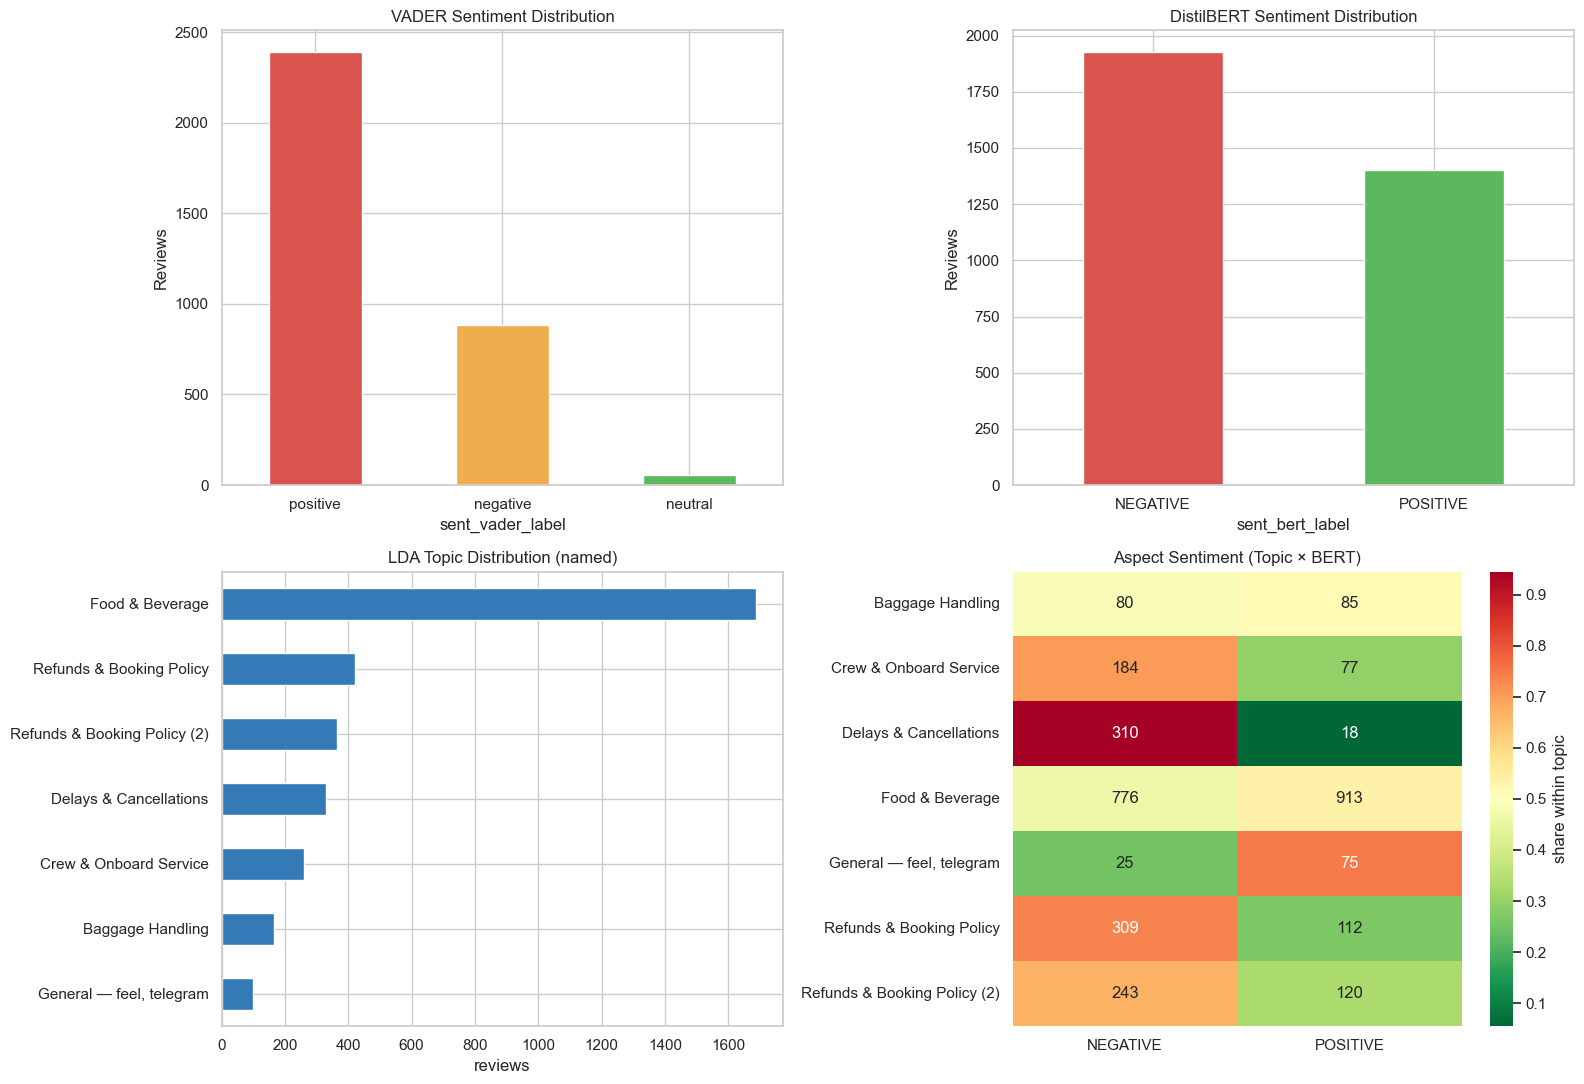

Saved overview figure: C:\Users\moham\SkyInsight\10_NLP\outputs_nlp\nlp_overview.png
VADER vs DistilBERT agreement (excluding neutral): 67.71%
VADER vs DistilBERT Cohen's kappa: 0.396


In [12]:
# 10) Visualization & Validation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Sentiment distributions
vader_counts = df_all["sent_vader_label"].value_counts()
vader_counts.plot(kind="bar", ax=axes[0, 0], color=["#d9534f", "#f0ad4e", "#5cb85c"][:len(vader_counts)])
axes[0, 0].set_title("VADER Sentiment Distribution")
axes[0, 0].set_ylabel("Reviews")
axes[0, 0].tick_params(axis="x", rotation=0)

bert_counts = df_all["sent_bert_label"].value_counts()
bert_counts.plot(kind="bar", ax=axes[0, 1], color=["#d9534f", "#5cb85c"][:len(bert_counts)])
axes[0, 1].set_title("DistilBERT Sentiment Distribution")
axes[0, 1].set_ylabel("Reviews")
axes[0, 1].tick_params(axis="x", rotation=0)

# Topic distribution — by LABEL (not numeric id)
topic_label_counts = (
    df_all["topic_label"].value_counts().sort_values(ascending=True)
)
topic_label_counts.plot(kind="barh", ax=axes[1, 0], color="#337ab7")
axes[1, 0].set_title("LDA Topic Distribution (named)")
axes[1, 0].set_xlabel("reviews")
axes[1, 0].set_ylabel("")

# Topic × Sentiment heatmap (aspect-based sentiment)
if "topic_label" in df_all.columns and "sent_bert_label" in df_all.columns:
    pivot = (
        df_all.groupby(["topic_label", "sent_bert_label"])
        .size().unstack(fill_value=0)
    )
    # Normalize to row share for interpretability
    pivot_pct = pivot.div(pivot.sum(axis=1).clip(lower=1), axis=0)
    sns.heatmap(pivot_pct, annot=pivot, fmt="d", cmap="RdYlGn_r",
                ax=axes[1, 1], cbar_kws={"label": "share within topic"})
    axes[1, 1].set_title("Aspect Sentiment (Topic × BERT)")
    axes[1, 1].set_xlabel(""); axes[1, 1].set_ylabel("")
else:
    axes[1, 1].axis("off")

plt.tight_layout()
viz_path = OUTPUT_DIR / "nlp_overview.png"
plt.savefig(viz_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved overview figure: {viz_path}")

# Cross-check VADER vs DistilBERT agreement (Phase 5 validation)
def vader_to_binary(lbl):
    if lbl == "positive":
        return "POSITIVE"
    if lbl == "negative":
        return "NEGATIVE"
    return None

mask = df_all["sent_vader_label"].apply(vader_to_binary).notna()
agree = (
    df_all.loc[mask, "sent_vader_label"].apply(vader_to_binary)
    == df_all.loc[mask, "sent_bert_label"]
).mean()
kappa = df_all.attrs.get("vader_bert_kappa")
print(f"VADER vs DistilBERT agreement (excluding neutral): {agree:.2%}")
print(f"VADER vs DistilBERT Cohen's kappa: {kappa if kappa is None else round(kappa, 3)}")
